In [15]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import math
import tensorflow_datasets as tfds
from ipywidgets import FileUpload
from IPython.display import display
from PIL import Image
import io

In [16]:
datos, metadatos = tfds.load("fashion_mnist", with_info=True, as_supervised=True)

print(metadatos)

tfds.core.DatasetInfo(
    name='fashion_mnist',
    full_name='fashion_mnist/3.0.1',
    description="""
    Fashion-MNIST is a dataset of Zalando's article images consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes.
    """,
    homepage='https://github.com/zalandoresearch/fashion-mnist',
    data_dir='C:\\Users\\panch\\tensorflow_datasets\\fashion_mnist\\3.0.1',
    file_format=tfrecord,
    download_size=29.45 MiB,
    dataset_size=36.42 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{DBLP

In [17]:
datos_entrenamiento, datos_prueba = datos["train"], datos["test"]
num_clases = metadatos.features["label"].num_classes
nombre_clases = metadatos.features["label"].names
print('Número de clases:', num_clases)
print('Nombre de clases:', nombre_clases)

Número de clases: 10
Nombre de clases: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [18]:
def normalizar(imagen, etiqueta):
    imagen = tf.cast(imagen, tf.float32)
    imagen /= 255
    return imagen, etiqueta

datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_prueba = datos_prueba.map(normalizar)
datos_entrenamiento = datos_entrenamiento.cache()
datos_prueba = datos_prueba.cache()

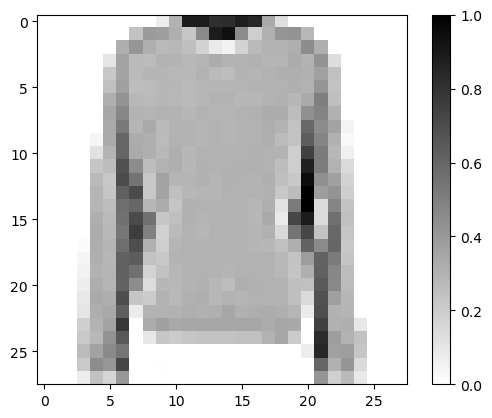

In [19]:
for imagen, etiqueta in datos_entrenamiento.take(1):
    break
imagen = imagen.numpy().reshape((28, 28))

plt.figure()
plt.imshow(imagen, cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.show()

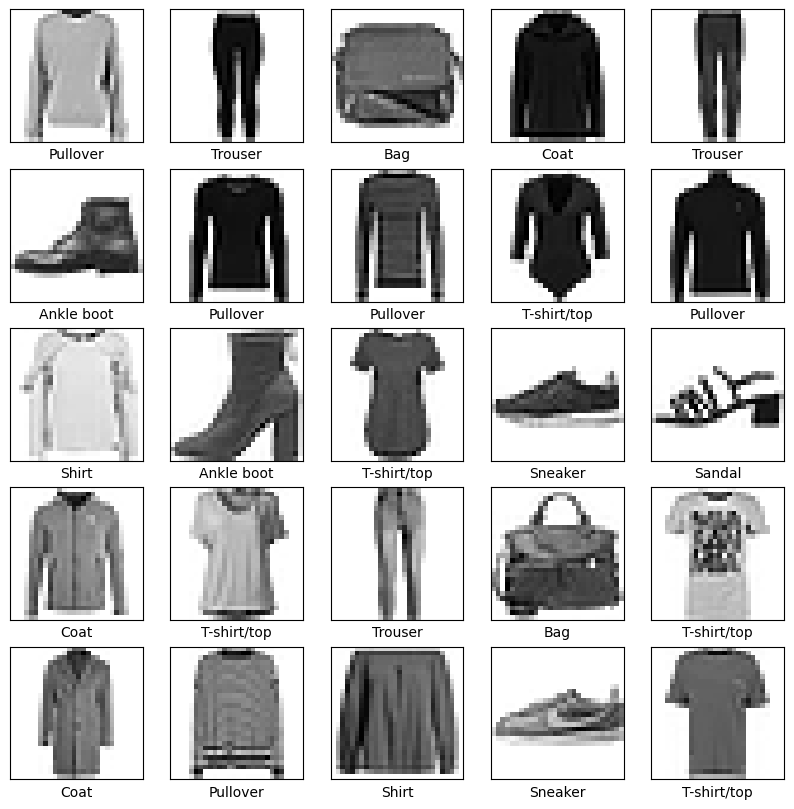

In [20]:
plt.figure(figsize=(10, 10))
for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(25)):
    imagen = imagen.numpy().reshape((28, 28))
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(imagen, cmap=plt.cm.binary)
    plt.xlabel(nombre_clases[etiqueta])
plt.show()

In [21]:
modelo = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [22]:
TAMANO_LOTE = 32
num_ejemplos_entrenamiento = metadatos.splits["train"].num_examples
num_ejemplos_prueba = metadatos.splits["test"].num_examples
print("Número de ejemplos de entrenamiento:", num_ejemplos_entrenamiento)
print("Número de ejemplos de prueba:", num_ejemplos_prueba)
datos_entrenamiento = datos_entrenamiento.repeat().shuffle(num_ejemplos_entrenamiento).batch(TAMANO_LOTE)
datos_prueba = datos_prueba.batch(TAMANO_LOTE)

Número de ejemplos de entrenamiento: 60000
Número de ejemplos de prueba: 10000


Epoch 1/5
1875/1875 [==============================] - 3s 986us/step - loss: 0.5199 - accuracy: 0.8169
Epoch 2/5
1875/1875 [==============================] - 2s 995us/step - loss: 0.3819 - accuracy: 0.8616
Epoch 3/5
1875/1875 [==============================] - 2s 965us/step - loss: 0.3454 - accuracy: 0.8748
Epoch 4/5
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3299 - accuracy: 0.8789
Epoch 5/5
1875/1875 [==============================] - 2s 984us/step - loss: 0.3047 - accuracy: 0.8876


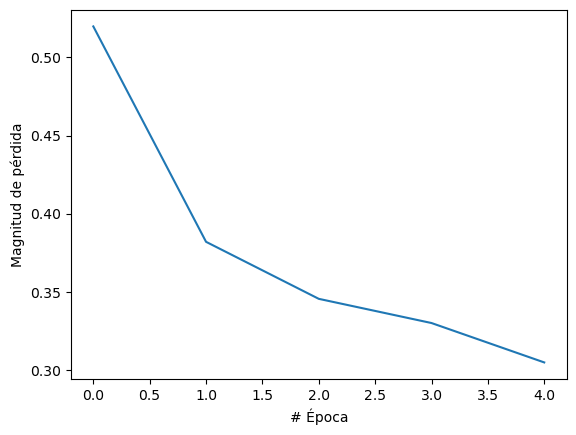

In [23]:
historial = modelo.fit(
    datos_entrenamiento,
    epochs=5,
    steps_per_epoch=math.ceil(num_ejemplos_entrenamiento / TAMANO_LOTE),
)

plt.xlabel("# Época")
plt.ylabel("Magnitud de pérdida")
plt.plot(historial.history["loss"])
plt.show()

In [24]:
for imagenes_prueba, etiquetas_prueba in datos_prueba.take(1):
    imagenes_prueba = imagenes_prueba.numpy()
    etiquetas_prueba = etiquetas_prueba.numpy()

predicciones = modelo.predict(imagenes_prueba)

def graficar_imagen(i, predicciones_array, etiqueta_real, imagen):
    predicciones_array, etiqueta_real, imagen = predicciones_array[i], etiqueta_real[i], imagen[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(imagen[..., 0], cmap=plt.cm.binary)

    etiqueta_predicha = np.argmax(predicciones_array)
    if etiqueta_predicha == etiqueta_real:
        color = "blue"
    else:
        color = "red"

    plt.xlabel("{} {:2.0f}% ({})".format(nombre_clases[etiqueta_predicha],
                                100 * np.max(predicciones_array),
                                nombre_clases[etiqueta_real]),
                                color=color)

1/1 [==============================] - 0s 37ms/step


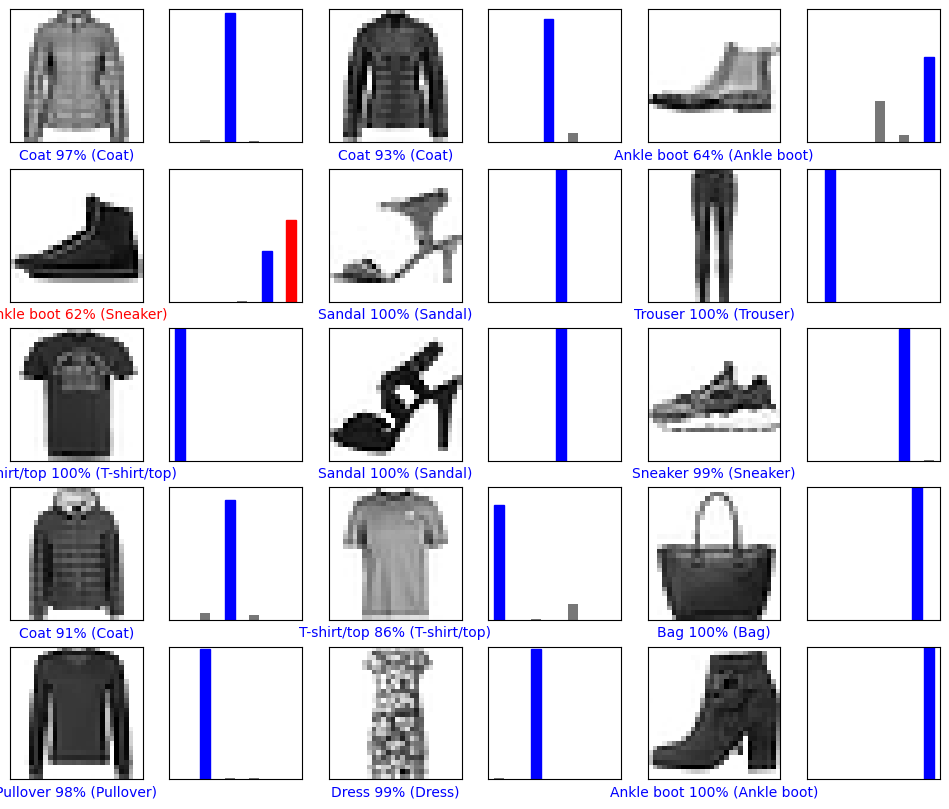

In [25]:
def graficar_valores_predichos(i, predicciones_array, etiqueta_real):
    predicciones_array, etiqueta_real = predicciones_array[i], etiqueta_real[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    grafica = plt.bar(range(10), predicciones_array, color="#777777")
    plt.ylim([0, 1])
    etiqueta_predicha = np.argmax(predicciones_array)

    grafica[etiqueta_predicha].set_color("red")
    grafica[etiqueta_real].set_color("blue")
    
num_filas = 5
num_columnas = 3
num_imagenes = num_filas * num_columnas
plt.figure(figsize=(2 * 2 * num_columnas, 2 * num_filas))
for i in range(num_imagenes):
    plt.subplot(num_filas, 2 * num_columnas, 2 * i + 1)
    graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)
    plt.subplot(num_filas, 2 * num_columnas, 2 * i + 2)
    graficar_valores_predichos(i, predicciones, etiquetas_prueba)

In [26]:
imagen = imagenes_prueba[24]
imagen = np.array([imagen])
prediccion = modelo.predict(imagen)
print("Predicción para la imagen de prueba 24:", nombre_clases[np.argmax(prediccion[0])])

1/1 [==============================] - 0s 42ms/step
Predicción para la imagen de prueba 24: Dress


FileUpload(value=(), accept='image/*', description='Upload')

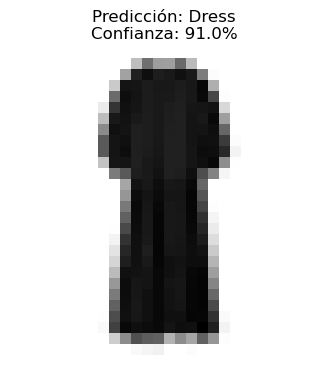

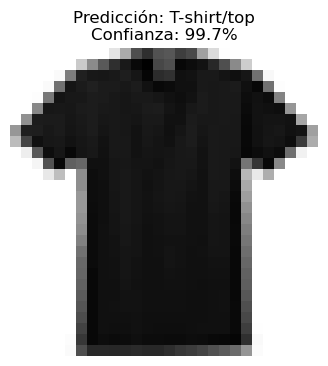

In [33]:
# Cargar una imagen personalizada

boton = FileUpload(accept="image/*", multiple=False)
display(boton)

def clasificar_imagen_usuario(change):
    # Obtengo el archivo subido
    archivo = boton.value[0]
    img_bytes = archivo["content"].tobytes()

    # Abro la imagen y la convierto a escala de grises (L)
    img = Image.open(io.BytesIO(img_bytes)).convert("L")

    # Redimensionar a 28x28 (tamaño que espera el modelo)
    img = img.resize((28, 28))

    # Convierto la imagen a un array de numpy y normalizo los valores a [0, 1]
    img_array = np.array(img, dtype=np.float32) / 255.0

    # Invertir colores: el modelo fue entrenado con fondo negro (0) y ropa blanca (1),
    # pero las imágenes comunes suelen tener fondo blanco (255) y ropa oscura (0)
    img_array = 1.0 - img_array

    # Le doy forma correcta que espera el modelo: (1, 28, 28, 1)
    img_array = img_array.reshape(1, 28, 28, 1)

    # Se hace la predicción
    prediccion = modelo.predict(img_array)
    clase_idx  = np.argmax(prediccion[0])
    confianza  = 100 * np.max(prediccion[0])

    plt.figure(figsize=(4, 4))
    plt.imshow(img_array[0, :, :, 0], cmap=plt.cm.binary)
    plt.title(f"Predicción: {nombre_clases[clase_idx]}\nConfianza: {confianza:.1f}%")
    plt.axis('off')
    plt.show()

    print(f"Categoría: {nombre_clases[clase_idx]}")
    print(f"Confianza: {confianza:.2f}%")


boton.observe(clasificar_imagen_usuario, names="value")

In [28]:
# Exportar el modelo al formato h5
modelo.save("modelo_tienda_ropa.h5")
print("Modelo guardado correctamente como 'modelo_tienda_ropa.h5'")

Modelo guardado correctamente como 'modelo_tienda_ropa.h5'


## Análisis y Discusión de Preguntas

**1. Parámetros de tfds.load()**

- as_supervised hace que los datos se devuelvan como tuplas (imagen, etiqueta) en lugar de un diccionario, que es el formato que Keras necesita para entrenar. 
-  with_info devuelve adicionalmente un objeto con los metadatos del dataset, como el número de ejemplos, nombres de clases y dimensiones de las imágenes.

**2. Función `map()`**

Se utiliza para aplicar una función a cada elemento del dataset de forma automática, le dice al código, a cada imagen del dataset, aplícale la función normalizar. En este proyecto se usa para normalizar cada imagen dividiendo sus píxeles entre 255, convirtiendo el rango de 0–255 a 0–1. Lo hace de forma eficiente sin cargar todo el dataset en memoria a la vez.

**3. Formato H5**

Es un formato de archivo estándar (HDF5) para almacenar grandes volúmenes de datos numéricos. En Keras permite guardar en un solo archivo la arquitectura de la red, los pesos entrenados y la configuración del optimizador. Esto es útil para reutilizar el modelo en el futuro sin necesidad de volver a entrenarlo.
